## Tarea M27 - CD-YAIR PALOMARES

In [23]:
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

os.chdir("C:/Users/yair_/OneDrive/Desktop/Ciencia de Datos/Módulo 7 - DataFrames")
data = pd.read_csv("iris.csv")
data

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [24]:
data = data.drop(columns="variety")
data

,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [25]:
from sklearn.cluster import KMeans
wcss = []
for index in range(1,11):
    kmeans = KMeans(n_clusters = index, init="k-means++", random_state=2)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

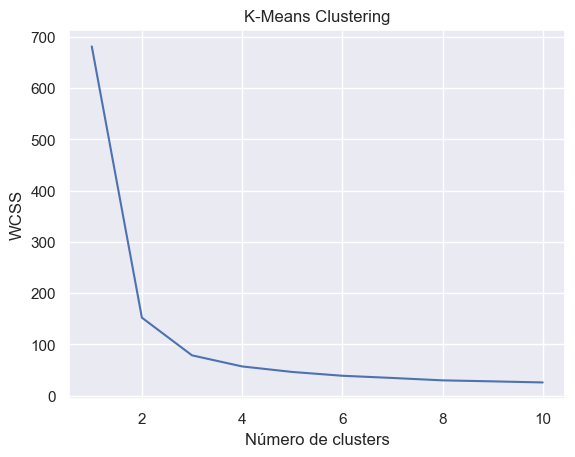

In [26]:
# Graficación del "Codo de Jambú"
sns.set()
mp.plot(range(1,11), wcss)
mp.title("K-Means Clustering")
mp.xlabel("Número de clusters")
mp.ylabel("WCSS") #Weighted cluster sum of squares

In [28]:
# Encontrar el número de grupos óptimo a través del "Criterio de Silueta (Silhouette)"
from sklearn import datasets
from sklearn.metrics import silhouette_score

In [29]:
x = data.to_numpy() #Se convierte a un arreglo numpy porque así lo requiere este comando
for j in range(2,12):
    kmeans = KMeans(n_clusters = j, random_state=42)
    kmeans.fit_predict(x)
    #Calculamos el score de Silueta
    score = silhouette_score(x, kmeans.labels_, metric="euclidean")
    print("Score Silhouette;", "k = ", j, ":", score)

Score Silhouette; k =  2 : 0.6810461692117467
Score Silhouette; k =  3 : 0.5528190123564101
Score Silhouette; k =  4 : 0.49805050499728803
Score Silhouette; k =  5 : 0.4887488870931063
Score Silhouette; k =  6 : 0.36483400396700355
Score Silhouette; k =  7 : 0.34974816211612175
Score Silhouette; k =  8 : 0.3574536925852726
Score Silhouette; k =  9 : 0.339448863639371
Score Silhouette; k =  10 : 0.2973144972185989
Score Silhouette; k =  11 : 0.318481930245191


In [30]:
kmeans = KMeans(n_clusters = 2, init="k-means++", random_state=42)
cluster_values = kmeans.fit_predict(data)
print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [40]:
# Reducción de dimensiones por PCA
from sklearn import decomposition
pca = decomposition.PCA(n_components=2)
pca.fit(x)
x = pca.transform(x)
x

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

In [41]:
from sklearn.cluster import KMeans
wcss2 = []
for index in range(1,11):
    kmeans = KMeans(n_clusters = index, init="k-means++", random_state=2)
    kmeans.fit(x)
    wcss2.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

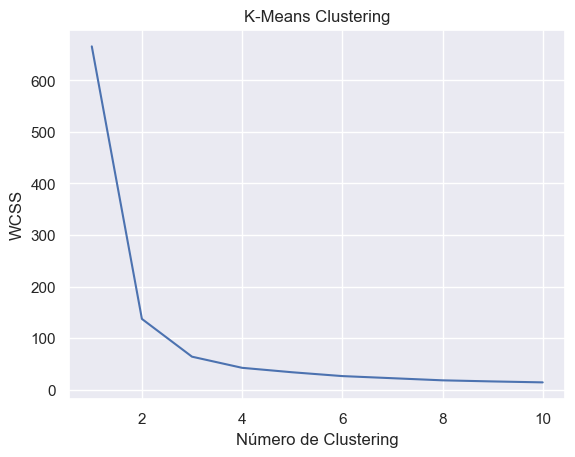

In [42]:
# Graficación del "Codo de Jambú"
sns.set()
mp.plot(range(1,11), wcss2)
mp.title("K-Means Clustering")
mp.xlabel("Número de Clustering")
mp.ylabel("WCSS") #Weighted cluster sum of squares

In [43]:
kmeans = KMeans(n_clusters = 2, init="k-means++", random_state=42)
cluster_values_PCA = kmeans.fit_predict(x)
print(cluster_values_PCA)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


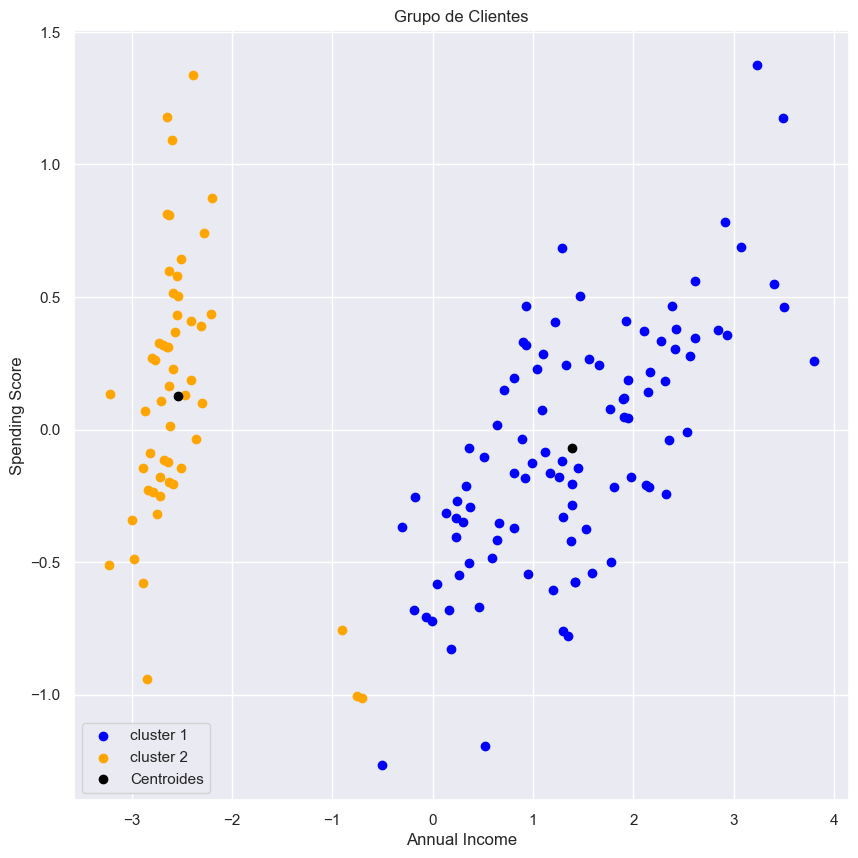

In [44]:
mp.figure(figsize=(10, 10))
mp.scatter(x[cluster_values_PCA==0, 0], x[cluster_values_PCA==0, 1], c="blue", label="cluster 1")
mp.scatter(x[cluster_values_PCA==1, 0], x[cluster_values_PCA==1, 1], c="orange", label="cluster 2")

mp.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c="black", label="Centroides")
mp.title("Grupo de Clientes")
mp.xlabel("Annual Income")
mp.ylabel("Spending Score")
mp.legend()

In [49]:
# Comparación de los dos resultados

if (cluster_values == cluster_values_PCA).all():
    print("Si se obtuvieron los mismos resultados de agrupamiento")
else:
    print("No se obtuvieron los mismos resultados de agrupamiento")

print("La ventaja de utilizar el método PCA al momento de agrupar por k-medias, es resumir los datos multivariables y lograr obtener una mejor visualización de los resultados del agrupamiento.")

Si se obtuvieron los mismos resultados de agrupamiento
La ventaja de utilizar el método PCA al momento de agrupar por k-medias, es resumir los datos multivariables y lograr obtener una mejor visualización de los resultados del agrupamiento.
